
## Title: Policy and Flow

## Headline 1: Inflation and Unemployment as Push Factors

In [12]:
import pandas as pd

# Load dataset (skip metadata rows)
infl = pd.read_csv("/Users/zaangwenya/Documents/finalised_data_science_lab/DataScienceLab_Migration/data_raw/Inflation Consumer Prices.csv", skiprows=4)

# Keep only Nigeria
infl_ng = infl[infl["Country Name"] == "Nigeria"]

# Drop unnecessary columns
infl_ng = infl_ng.drop(columns=["Country Code", "Indicator Name", "Indicator Code"])

# Convert from wide → long format
infl_long = infl_ng.melt(
    id_vars=["Country Name"],
    var_name="Year",
    value_name="Inflation"
)

# Clean data
infl_long["Year"] = pd.to_numeric(infl_long["Year"], errors="coerce")
infl_long["Inflation"] = pd.to_numeric(infl_long["Inflation"], errors="coerce")

# Remove missing values
infl_long = infl_long.dropna()

infl_long = infl_long[infl_long["Year"] >= 2000]

# Sort by year
infl_long = infl_long.sort_values("Year")

# Save clean file
infl_long.to_csv("nigeria_inflation_clean.csv", index=False)

print(infl_long.head())

   Country Name    Year  Inflation
40      Nigeria  2000.0   6.933292
41      Nigeria  2001.0  18.873646
42      Nigeria  2002.0  12.876579
43      Nigeria  2003.0  14.031784
44      Nigeria  2004.0  14.998034


⬆:This script cleans Nigerian inflation data for easier analysis. It removes unnecessary metadata and reshapes the dataset from wide to long format using the melt function ensuring all values are numeric. It also filters the data from the year 2000 onwards and sorts it chronologically. The same cleaning approach can also be applied to unemployment and labor force datasets since they come from the same source(The World Bank).

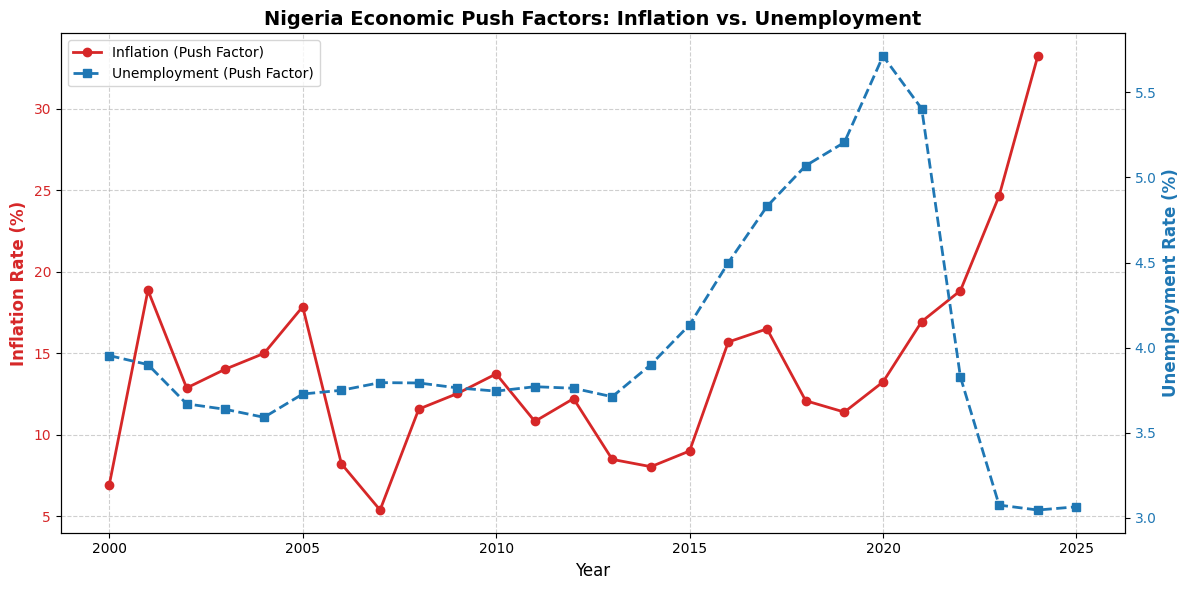

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data from your CSV files
# Ensure the file names below match your actual filenames exactly
try:
    df_inf = pd.read_csv('/Users/zaangwenya/Documents/finalised_data_science_lab/DataScienceLab_Migration/data_processed/clean_in.csv')
    df_unemp = pd.read_csv('/Users/zaangwenya/Documents/finalised_data_science_lab/DataScienceLab_Migration/data_processed/clean_un.csv')
except FileNotFoundError:
    print("Error: Ensure your CSV files are in the same folder as this script.")

# 2. Setup the figure and the first axis (Inflation)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Inflation (Primary Y-Axis)
color_inf = 'tab:red'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Inflation Rate (%)', color=color_inf, fontsize=12, fontweight='bold')
ax1.plot(df_inf['Year'], df_inf['Inflation Rate'], color=color_inf, marker='o', label='Inflation (Push Factor)', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color_inf)
ax1.grid(True, linestyle='--', alpha=0.6)

# 3. Setup the second axis (Unemployment)
ax2 = ax1.twinx()
color_unemp = 'tab:blue'
ax2.set_ylabel('Unemployment Rate (%)', color=color_unemp, fontsize=12, fontweight='bold')
ax2.plot(df_unemp['Year'], df_unemp['Unemployment Rate'], color=color_unemp, marker='s', label='Unemployment (Push Factor)', linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color_unemp)

# 4. Final touches
plt.title('Nigeria Economic Push Factors: Inflation vs. Unemployment', fontsize=14, fontweight='bold')
fig.tight_layout()

# Add a combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# 5. Display the graph
plt.show()


⬆:This graph visualizes the relationship between Nigeria's Inflation Rate (red solid line) and Unemployment Rate (blue dashed line) from 2000 to 2025. It employs a dual-axis design to manage the different scales of the two metrics, with inflation measured on the left axis and unemployment on the right.


For the first fifteen years (2000–2015), both indicators fluctuated within a relatively stable range. Inflation generally stayed between 5% and 20% while unemployment remained low and steady, hovering near 4%. However, the period after 2015 marks a significant shift in economic stability. Unemployment saw a dramatic surge, peaking at nearly 5.8% around 2020 due to Covid before experiencing a sharp decline toward 3% by 2023.


In contrast, inflation has followed an aggressive upward trajectory in recent years. While it dipped slightly around 2020, it skyrocketed after 2021, breaking past 30% by 2024. This creates a striking divergence in the final years of the plot as unemployment figures appear to have stabilized at a historic low, inflation has surged to a historic high, suggesting that soaring costs of living have replaced job availability as the primary economic "push factor" for the country.

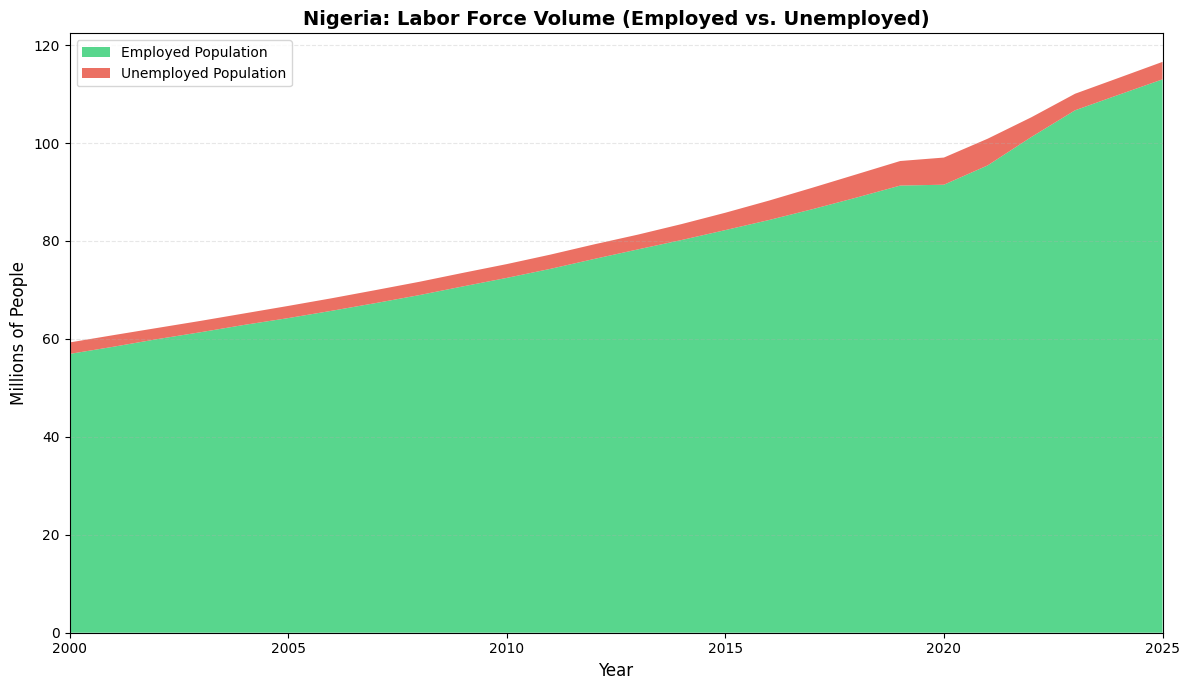

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Labor Force data
df_total = pd.read_csv('/Users/zaangwenya/Documents/finalised_data_science_lab/DataScienceLab_Migration/data_processed/clean_labor_force.csv')
df_total.columns = df_total.columns.str.strip()  # remove extra spaces

# Filter for Nigeria
df_ng_total = df_total[df_total['Country Name'] == 'Nigeria'].copy()

# Ensure 'Year' is numeric
df_ng_total['Year'] = pd.to_numeric(df_ng_total['Year'])

# 2. Load Unemployment Rate data
df_unemp = pd.read_csv('/Users/zaangwenya/Documents/finalised_data_science_lab/DataScienceLab_Migration/data_processed/clean_un.csv')
df_unemp.columns = df_unemp.columns.str.strip()
df_unemp['Year'] = pd.to_numeric(df_unemp['Year'])

# 3. Merge datasets on 'Year'
df_combined = pd.merge(df_ng_total, df_unemp, on='Year')

# 4. Calculate Employed and Unemployed counts
df_combined['Unemployed_Count'] = (df_combined['Unemployment Rate'] / 100) * df_combined['Total_Labor_Force']
df_combined['Employed_Count'] = df_combined['Total_Labor_Force'] - df_combined['Unemployed_Count']

# 5. Plot Stacked Area Chart
plt.figure(figsize=(12, 7))

plt.stackplot(
    df_combined['Year'],
    df_combined['Employed_Count'] / 1e6,
    df_combined['Unemployed_Count'] / 1e6,
    labels=['Employed Population', 'Unemployed Population'],
    colors=['#2ecc71', '#e74c3c'],
    alpha=0.8
)

plt.title('Nigeria: Labor Force Volume (Employed vs. Unemployed)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Millions of People', fontsize=12)
plt.xlim(df_combined['Year'].min(), df_combined['Year'].max())
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

⬆:This stacked area chart provides a comprehensive look at Nigeria's growing labor force from 2000 to 2025, but its visual representation of employment (the green area) requires a critical economic lens to understand the reality on the ground. At a glance, the total labor force shows a massive, steady expansion, nearly doubling from 60 million to over 110 million people, which illustrates the country's significant demographic youth bulge. While the red area representing unemployment appears to shrink significantly after 2020, this trend is largely a reflection of a controversial shift in data methodology rather than a sudden abundance of high quality jobs.


The sharp drop in the red unemployed section corresponds with the 1-hour working rule adopted by the National Bureau of Statistics (NBS) in 2023 to align with International Labour Organization (ILO) standards. Under this definition, anyone who engages in at least one hour of economic activity for pay or profit in the preceding seven days is classified as "employed". This includes everything from small scale trade and subsistence farming to running minor errands. Consequently, the vast green area on the chart masks a deep seated crisis of underemployment and working poverty, where millions are technically employed but earn far too little to survive amidst Nigeria's triple digit inflation and a depreciated Naira.


This disconnect between statistical employment and economic stability is the primary driver of the "Japa" phenomenon, where skilled and unskilled Nigerians alike seek work elsewhere. Even though the chart shows a large employed population, the economy remains volatile due to soaring fuel prices, a high misery index, and a cost of living crisis that has outpaced the new minimum wage. For many represented in that green area, employment does not mean a stable career or financial security, instead, it represents a survival struggle that pushes them to look for better opportunities beyond Nigeria's borders.


# Part 1b: Policy and Flows

## Research focus
This section examines whether changes in UK migration policy are associated with changes in migrant inflows over time. The policy dimension is measured using the DEMIG/MIGPOL dataset for the United Kingdom, while migrant inflows are captured using the migration totals dataset. 

To maintain consistency with the rest of the group project, all analysis is aligned to **five-year periods** rather than yearly observations. This makes the results easier to compare across team members and reduces short-term volatility in the data.

## Analytical objective
The aim is to determine whether migration inflows appear to increase during periods of greater policy openness, or whether migrant movements continue to rise regardless of policy fluctuations. This allows us to assess the role of UK policy as a pull factor in shaping migration flows.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 1. LOAD DATA
# ----------------------------

policy_raw = pd.read_csv('complab_migpol_demig_quantmig_cleaned.csv', encoding='latin1')
migration_raw = pd.read_csv('nigeria_migrant_totals(Totals).csv')

print("Policy data shape:", policy_raw.shape)
print("Migration data shape:", migration_raw.shape)

print("\nPolicy columns:")
print(policy_raw.columns.tolist())

print("\nMigration data preview:")
print(migration_raw.head())

Policy data shape: (9051, 18)
Migration data shape: (6, 2)

Policy columns:
['year', 'iso2', 'change_id', 'iso3', 'country_full_name', 'summary', 'change_mag', 'change_level', 'pol_area', 'pol_tool', 'target_group', 'target_origin', 'target_specific', 'change_restrict', 'u_complab_country_year_change_country', 'u_complab_country_year_change_country_code', 'u_complab_country_year_change_year', 'u_complab_country_year_change_change']

Migration data preview:
   Year  Total Migrants
0  2000           83822
1  2005          125003
2  2010          189847
3  2015          236603
4  2020          286251


### Interpretation
The first step is to load both the policy and migration datasets. This is necessary because the analysis combines two different sources: a policy database and a migration inflow series. Inspecting the structure of both files helps confirm that the data has loaded correctly and that the necessary variables are available for the analysis.

In [4]:
# ----------------------------
# 2. FILTER POLICY DATA FOR UK
# ----------------------------

policy_raw['country_full_name'] = policy_raw['country_full_name'].astype(str).str.strip()
policy_uk = policy_raw[policy_raw['country_full_name'] == 'United Kingdom'].copy()

print("UK policy data shape:", policy_uk.shape)
policy_uk.head()

UK policy data shape: (262, 18)


,year,iso2,change_id,iso3,country_full_name,summary,change_mag,change_level,pol_area,pol_tool,target_group,target_origin,target_specific,change_restrict,u_complab_country_year_change_country,u_complab_country_year_change_country_code,u_complab_country_year_change_year,u_complab_country_year_change_change
172,1905.0,GB,GB1905001,GBR,United Kingdom,first immigration controls,0.0,4.0,1.0,1.0,2.0,2.0,Non applicable,1.0,United Kingdom,GBR,1905,GB1905001
173,1905.0,GB,GB1905002,GBR,United Kingdom,British nationals retained their right to ente...,0.0,3.0,2.0,16.0,1.0,4.0,"Commonwealth countries, colonies and former co...",-1.0,United Kingdom,GBR,1905,GB1905002
174,1905.0,GB,GB1905003,GBR,United Kingdom,entry ban on undesirables,0.0,3.0,2.0,13.0,14.0,2.0,Non applicable,1.0,United Kingdom,GBR,1905,GB1905003
175,1905.0,GB,GB1905004,GBR,United Kingdom,deportation mechanism for criminals and paupers,0.0,3.0,4.0,24.0,14.0,2.0,Non applicable,1.0,United Kingdom,GBR,1905,GB1905004
176,1905.0,GB,GB1905005,GBR,United Kingdom,distribution of competence to Home secretary,0.0,4.0,2.0,26.0,1.0,1.0,Non applicable,9.0,United Kingdom,GBR,1905,GB1905005


### Interpretation
Because the research question focuses on migration into the United Kingdom, only UK policy observations are retained. This ensures that the policy measure directly reflects the immigration environment of the destination country under study.

In [5]:
# ----------------------------
# 3. CLEAN POLICY DIRECTION
# ----------------------------

policy_uk['change_restrict'] = pd.to_numeric(policy_uk['change_restrict'], errors='coerce')

print(policy_uk['change_restrict'].value_counts(dropna=False))

change_restrict
 1.0      120
-1.0       89
 999.0     32
 9.0       12
 0.0        9
Name: count, dtype: int64


### Interpretation
The variable `change_restrict` captures the direction of policy change. Before constructing a policy index, it is necessary to inspect how this variable is coded so that only meaningful and interpretable policy changes are retained.

In [6]:
# Keep only clearly interpretable policy directions
policy_uk = policy_uk[policy_uk['change_restrict'].isin([-1.0, 1.0])].copy()

print("Filtered UK policy data shape:", policy_uk.shape)
print(policy_uk['change_restrict'].value_counts())

Filtered UK policy data shape: (209, 18)
change_restrict
 1.0    120
-1.0     89
Name: count, dtype: int64


### Interpretation
Only clearly interpretable policy changes are kept:

- `-1.0` = liberalizing policy change
- `1.0` = restrictive policy change

All other values are excluded because they do not clearly indicate usable policy direction. This improves the reliability of the policy measure used in the analysis.

In [7]:
# ----------------------------
# 4. RECODE FOR EASIER INTERPRETATION
# ----------------------------

# Reverse the sign so that:
# +1 = more open
# -1 = more restrictive
policy_uk['policy_signed'] = -policy_uk['change_restrict']

policy_uk[['year', 'change_restrict', 'policy_signed']].head()

,year,change_restrict,policy_signed
172,1905.0,1.0,-1.0
173,1905.0,-1.0,1.0
174,1905.0,1.0,-1.0
175,1905.0,1.0,-1.0
239,1914.0,1.0,-1.0


### Interpretation
The sign of the policy variable is reversed so that the final series becomes easier to interpret visually. After recoding:

- positive values indicate greater policy openness
- negative values indicate greater policy restrictiveness

This makes the charts more intuitive and improves the clarity of the written interpretation.

In [8]:
# ----------------------------
# 5. CREATE YEARLY POLICY SERIES
# ----------------------------

policy_year = (
    policy_uk.groupby('year')['policy_signed']
    .sum()
    .reset_index()
    .rename(columns={'policy_signed': 'PolicyChange'})
)

policy_year['PolicyIndex'] = policy_year['PolicyChange'].cumsum()

print(policy_year.head(10))
print(policy_year.tail(10))

     year  PolicyChange  PolicyIndex
0  1905.0          -2.0         -2.0
1  1914.0          -2.0         -4.0
2  1919.0          -1.0         -5.0
3  1923.0           1.0         -4.0
4  1939.0          -1.0         -5.0
5  1945.0           1.0         -4.0
6  1946.0           1.0         -3.0
7  1947.0           1.0         -2.0
8  1949.0           2.0          0.0
9  1953.0           1.0          1.0
      year  PolicyChange  PolicyIndex
39  2010.0           0.0        -24.0
40  2011.0          -3.0        -27.0
41  2012.0          -2.0        -29.0
42  2013.0           3.0        -26.0
43  2014.0         -12.0        -38.0
44  2015.0          -5.0        -43.0
45  2016.0           1.0        -42.0
46  2017.0           2.0        -40.0
47  2018.0           4.0        -36.0
48  2019.0           5.0        -31.0


### Interpretation
This step first aggregates individual policy events into a yearly net policy change measure. A positive annual value means liberalizing policy changes outweighed restrictive ones in that year, while a negative annual value means restriction dominated.

The cumulative policy index is then constructed to show the broader policy trajectory over time. This is more useful than isolated annual values because it captures the longer-run policy environment facing migrants.

In [9]:
# ----------------------------
# 6. ALIGN POLICY DATA TO TEAM PERIOD
# ----------------------------

policy_year = policy_year.set_index('year').reindex(range(2000, 2027))

# Carry the cumulative index forward where later DEMIG data is unavailable
policy_year['PolicyIndex'] = policy_year['PolicyIndex'].ffill()

# For missing annual years, treat as no newly observed policy change
policy_year['PolicyChange'] = policy_year['PolicyChange'].fillna(0)

policy_year = policy_year.reset_index().rename(columns={'index': 'year'})

print(policy_year.head(10))
print(policy_year.tail(10))

   year  PolicyChange  PolicyIndex
0  2000           4.0         -5.0
1  2001           2.0         -3.0
2  2002          -4.0         -7.0
3  2003           2.0         -5.0
4  2004          -1.0         -6.0
5  2005          -1.0         -7.0
6  2006          -6.0        -13.0
7  2007          -3.0        -16.0
8  2008          -3.0        -19.0
9  2009          -5.0        -24.0
    year  PolicyChange  PolicyIndex
17  2017           2.0        -40.0
18  2018           4.0        -36.0
19  2019           5.0        -31.0
20  2020           0.0        -31.0
21  2021           0.0        -31.0
22  2022           0.0        -31.0
23  2023           0.0        -31.0
24  2024           0.0        -31.0
25  2025           0.0        -31.0
26  2026           0.0        -31.0


### Interpretation
The group is working within the time period 2000–2026, so the policy series is aligned to that same period. Because the DEMIG/MIGPOL dataset may not provide coded policy observations up to 2026, the cumulative policy environment is carried forward after the last observed year.

This does not mean that new policy changes were directly observed in those later years. Rather, it means that the last available policy position is used as the best available approximation for alignment purposes. This assumption should be stated clearly as a methodological limitation.

In [10]:
# ----------------------------
# 7. CLEAN MIGRATION DATA
# ----------------------------

migration_df = migration_raw.copy()
migration_df.columns = ['year', 'Migration']
migration_df = migration_df.sort_values('year').reset_index(drop=True)

print(migration_df)

   year  Migration
0  2000      83822
1  2005     125003
2  2010     189847
3  2015     236603
4  2020     286251
5  2024     324007


### Interpretation
The migration dataset is simplified into two variables: year and total migrant inflows. This prepares the data for direct comparison with the UK policy series.

In [11]:
# ----------------------------
# 8. ALIGN BOTH DATASETS TO 5-YEAR PERIODS
# ----------------------------

# Keep policy at years relevant to the team's 5-year structure
policy_5yr = policy_year[policy_year['year'].isin([2000, 2005, 2010, 2015, 2020, 2024, 2025])].copy()

# Because migration data includes 2024, we can keep 2024 as an observed point.
# If you want strict 5-year only, remove 2024 and stop at 2020.
print(policy_5yr)
print(migration_df)

    year  PolicyChange  PolicyIndex
0   2000           4.0         -5.0
5   2005          -1.0         -7.0
10  2010           0.0        -24.0
15  2015          -5.0        -43.0
20  2020           0.0        -31.0
24  2024           0.0        -31.0
25  2025           0.0        -31.0
   year  Migration
0  2000      83822
1  2005     125003
2  2010     189847
3  2015     236603
4  2020     286251
5  2024     324007


### Interpretation
The project is being aligned to five-year intervals in order to remain consistent with the broader group analysis. This reduces short-term fluctuation and makes the results easier to compare across sections of the project.

Where migration data includes 2024 rather than 2025, that observation can still be retained as the latest available point, provided the report clearly states that the final observation is not a perfect five-year interval.

In [12]:
# ----------------------------
# 9. MERGE POLICY AND MIGRATION
# ----------------------------

# Merge on the overlapping observed years
merged_5yr = policy_5yr.merge(migration_df, on='year', how='inner')

print(merged_5yr)
print("Merged 5-year shape:", merged_5yr.shape)

   year  PolicyChange  PolicyIndex  Migration
0  2000           4.0         -5.0      83822
1  2005          -1.0         -7.0     125003
2  2010           0.0        -24.0     189847
3  2015          -5.0        -43.0     236603
4  2020           0.0        -31.0     286251
5  2024           0.0        -31.0     324007
Merged 5-year shape: (6, 4)


### Interpretation
This step creates the core analytical dataset for Part 1. It combines the policy index and migrant inflows into one table using the common time points shared by both datasets. This allows the relationship between UK policy and migration flows to be examined directly.

In [13]:
# ----------------------------
# 10. STANDARDIZE FOR COMPARISON
# ----------------------------

merged_5yr['Policy_norm'] = (
    (merged_5yr['PolicyIndex'] - merged_5yr['PolicyIndex'].mean()) /
    merged_5yr['PolicyIndex'].std()
)

merged_5yr['Migration_norm'] = (
    (merged_5yr['Migration'] - merged_5yr['Migration'].mean()) /
    merged_5yr['Migration'].std()
)

print(merged_5yr[['year', 'PolicyIndex', 'Migration', 'Policy_norm', 'Migration_norm']])

   year  PolicyIndex  Migration  Policy_norm  Migration_norm
0  2000         -5.0      83822     1.243039       -1.334051
1  2005         -7.0     125003     1.108657       -0.890172
2  2010        -24.0     189847    -0.033596       -0.191235
3  2015        -43.0     236603    -1.310231        0.312736
4  2020        -31.0     286251    -0.503935        0.847879
5  2024        -31.0     324007    -0.503935        1.254842


### Interpretation
The policy index and migration totals are measured on very different numerical scales, so plotting them directly would make comparison difficult. Standardization solves this problem by converting each series into relative values based on its own mean and standard deviation. This makes it possible to compare their movements over time on the same graph.

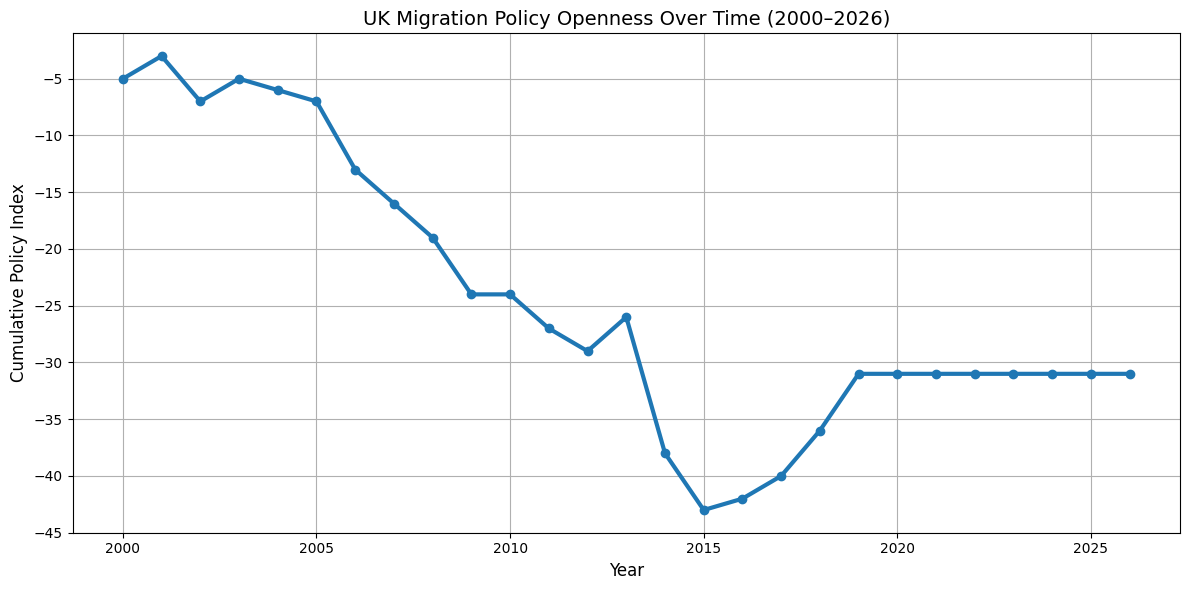

In [19]:
# ----------------------------
# 11. VISUALIZATION 1:
# POLICY EVOLUTION OVER TIME
# ----------------------------

plt.figure(figsize=(12,6))

plt.plot(
    policy_year['year'],
    policy_year['PolicyIndex'],
    marker='o',
    linewidth=3
)

plt.title('UK Migration Policy Openness Over Time (2000–2026)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Cumulative Policy Index', fontsize=12)

plt.grid(True)

plt.tight_layout()
plt.show()

### Interpretation of Visualization 1
This figure shows the long-run evolution of UK migration policy across the selected time points. Because the measure is cumulative, the graph reflects the overall direction of the UK migration environment rather than isolated one-year policy events.

An upward movement in the index suggests that liberalizing policy changes have had greater cumulative influence, while a downward or flatter pattern suggests a relatively more restrictive or stable policy environment. This chart is important because it establishes the pull-factor context within which migrants enter the UK.

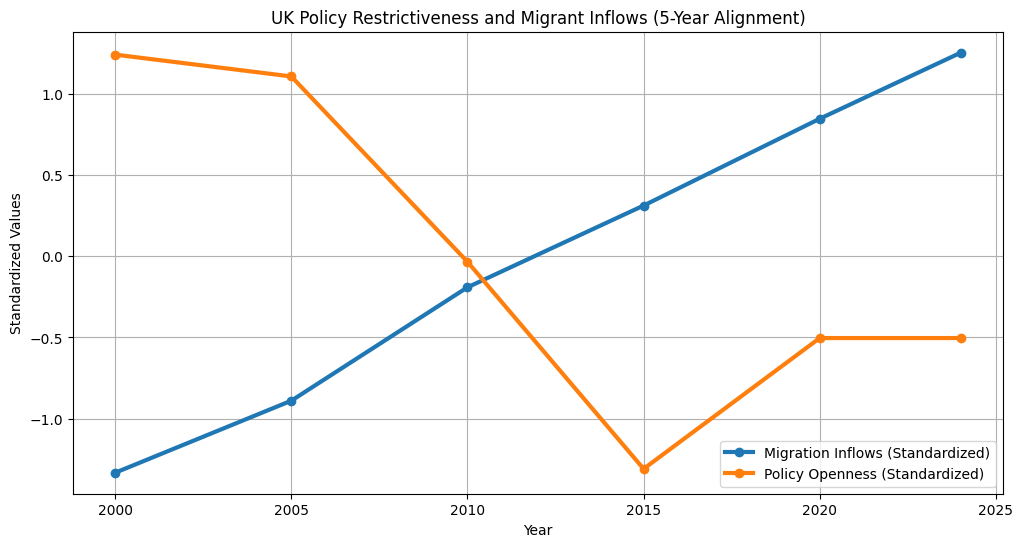

In [ ]:
# ----------------------------
# 12. VISUALIZATION 2:
# POLICY VS MIGRATION
# ----------------------------

plt.figure(figsize=(12,6))

plt.plot(
    merged_5yr['year'],
    merged_5yr['Migration_norm'],
    marker='o',
    linewidth=3,
    label='Migration Inflows'
)

plt.plot(
    merged_5yr['year'],
    merged_5yr['Policy_norm'],
    marker='o',
    linewidth=3,
    linestyle='--',
    label='Policy Openness'
)

plt.title('UK Policy Restrictiveness vs Migration Inflows (5-Year Alignment)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Standardized Values', fontsize=12)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Interpretation of Visualization 2
This is the central comparison graph for Part 1. It places migrant inflows and UK policy on the same standardized scale so that their movements can be compared directly.

There are several possible interpretations:

- If the two lines rise and fall together, this suggests that policy changes may be associated with migrant inflows.
- If migrant inflows rise steadily while policy fluctuates, this suggests that migration is influenced by other structural forces beyond policy alone.
- If migrant inflows appear to respond only after policy shifts, this may indicate a delayed effect of policy changes on migration.

This graph therefore provides the clearest visual test of whether migration flows seem responsive to the UK policy environment.

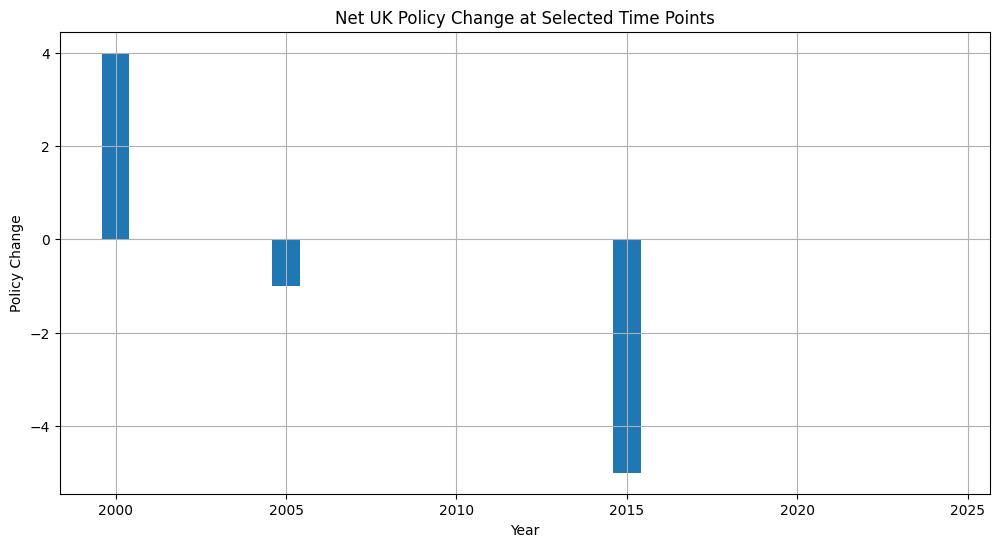

In [16]:
# ----------------------------
# 13. VISUALIZATION 3:
# ANNUAL POLICY CHANGE AT 5-YEAR POINTS
# ----------------------------

plt.figure(figsize=(12,6))
plt.bar(merged_5yr['year'], merged_5yr['PolicyChange'])

plt.title('Net UK Policy Change at Selected Time Points')
plt.xlabel('Year')
plt.ylabel('Policy Change')
plt.grid(True)
plt.show()

### Interpretation of Visualization 3
This chart focuses on policy shifts rather than the cumulative policy environment. It helps show whether the observed time points correspond to moments of stronger policy openness or stronger restriction.

Where the cumulative graph captures the broad trajectory of migration policy, this graph highlights the change component more directly. It can therefore support discussion of whether particular policy turning points may have shaped migration conditions.

In [17]:
# ----------------------------
# 14. CORRELATION
# ----------------------------

correlation = merged_5yr[['Policy_norm', 'Migration_norm']].corr()
print(correlation)

                Policy_norm  Migration_norm
Policy_norm        1.000000       -0.821628
Migration_norm    -0.821628        1.000000


### Interpretation
The correlation coefficient provides a simple numerical summary of the relationship between policy openness and migrant inflows across the five-year aligned observations. A positive correlation would indicate that more open policy periods tend to coincide with higher inflows, while a negative correlation would indicate the opposite.

However, this should not be treated as proof of causation. It is only an initial indication of association and should be interpreted alongside the visual evidence.

In [18]:
# ----------------------------
# 15. SUMMARY STATISTICS
# ----------------------------

summary_stats = merged_5yr[['PolicyIndex', 'Migration', 'Policy_norm', 'Migration_norm']].describe()
print(summary_stats)

       PolicyIndex      Migration  Policy_norm  Migration_norm
count     6.000000       6.000000     6.000000    6.000000e+00
mean    -23.500000  207588.833333     0.000000   -1.480297e-16
std      14.882876   92775.179238     1.000000    1.000000e+00
min     -43.000000   83822.000000    -1.310231   -1.334051e+00
25%     -31.000000  141214.000000    -0.503935   -7.154374e-01
50%     -27.500000  213225.000000    -0.268765    6.075080e-02
75%     -11.250000  273839.000000     0.823094    7.140937e-01
max      -5.000000  324007.000000     1.243039    1.254842e+00


### Interpretation
The summary statistics provide an overview of the central tendency and variation of the main variables in the five-year analytical dataset. This supports the descriptive part of the analysis and helps show how much the two series vary across the study period.

# Final Discussion

The five-year aligned analysis provides a consistent framework for examining the relationship between UK migration policy and migrant inflows. The cumulative policy index captures the broader direction of UK policy, while the migration series reflects how inflows changed over the same broad periods.

The visual evidence can be interpreted in three main ways. First, if migration and policy move together, this suggests that UK policy may play an important role in shaping migrant inflows. Second, if migration rises steadily even when policy becomes less open, this suggests that policy is only one part of a wider migration process. Third, if migration appears to respond after policy changes rather than immediately, this suggests that the effect of policy may be delayed.

Overall, this section provides the pull-factor side of the project. It establishes whether the UK migration environment appears to facilitate or constrain migrant inflows, and it creates a clear foundation for later comparison with Nigeria’s economic push factors..

